# Laboratorium 4 - Efekt Rungego
## Zadanie 1
Porównanie średniej geometrycznej odległości punktów od siebie dla różnych rozkładów węzłów.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def geometric_mean_distances(nodes):
    n = len(nodes)
    distances = []
    for x in nodes:
        dist = np.prod([np.abs(x - xi) for xi in nodes if xi != x])
        distances.append(dist ** (1.0 / (n - 1)))
    return np.array(distances)

def chebyshev_nodes(n, a=-1, b=1):
    j = np.arange(1, n + 1)
    nodes = np.cos((2 * j - 1) / (2 * n) * np.pi)
    return 0.5 * (a + b) + 0.5 * (b - a) * nodes

def legendre_nodes(n):
    coeffs = [0] * n + [1]
    return np.polynomial.legendre.legroots(coeffs)

def equidistant_nodes(n, a=-1, b=1):
    return np.linspace(a, b, n)


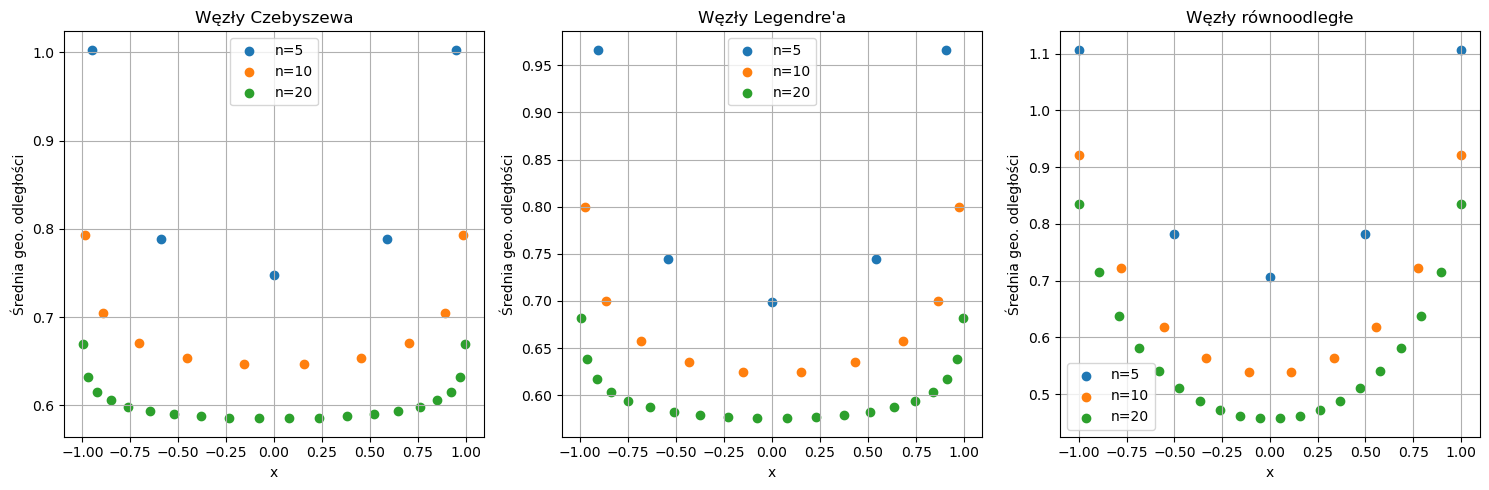

In [4]:
ns = [5, 10, 20]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['Węzły Czebyszewa', 'Węzły Legendre\'a', 'Węzły równoodległe']
node_funcs = [chebyshev_nodes, legendre_nodes, equidistant_nodes]

for ax, title, func in zip(axes, titles, node_funcs):
    for n in ns:
        nodes = func(n)
        y = geometric_mean_distances(nodes)
        ax.scatter(nodes, y, label=f'n={n}')
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('Średnia geo. odległości')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


## Zadanie 2
Interpolacja funkcji $f_1(x) = \frac{1}{1+25x^2}$ oraz $f_2(x) = e^{\cos(x)}$.

In [5]:
def f1(x):
    return 1.0 / (1.0 + 25.0 * x**2)

def f2(x):
    return np.exp(np.cos(x))

def lagrange_interpolation(x, x_nodes, y_nodes):
    n = len(x_nodes)
    result = np.zeros_like(x, dtype=float)
    for i in range(n):
        term = y_nodes[i]
        for j in range(n):
            if i != j:
                term = term * (x - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
        result += term
    return result


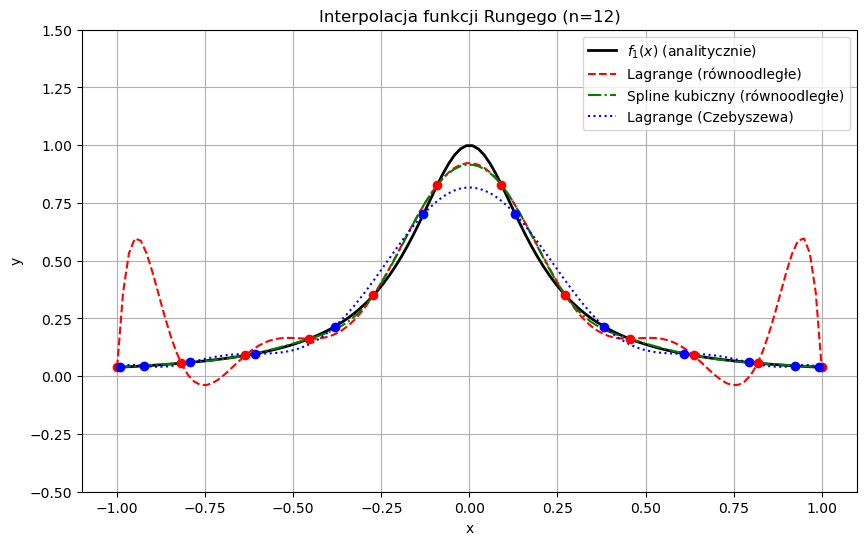

In [6]:
# Podpunkt (a)
n = 12
x_dense = np.linspace(-1, 1, n * 10)
y_true = f1(x_dense)

x_eq = equidistant_nodes(n)
y_eq = f1(x_eq)
y_lagrange_eq = lagrange_interpolation(x_dense, x_eq, y_eq)

spline = interp1d(x_eq, y_eq, kind='cubic')
y_spline_eq = spline(x_dense)

x_cheb = chebyshev_nodes(n)
y_cheb = f1(x_cheb)
y_lagrange_cheb = lagrange_interpolation(x_dense, x_cheb, y_cheb)

plt.figure(figsize=(10, 6))
plt.plot(x_dense, y_true, 'k-', label='$f_1(x)$ (analitycznie)', linewidth=2)
plt.plot(x_dense, y_lagrange_eq, 'r--', label='Lagrange (równoodległe)')
plt.plot(x_dense, y_spline_eq, 'g-.', label='Spline kubiczny (równoodległe)')
plt.plot(x_dense, y_lagrange_cheb, 'b:', label='Lagrange (Czebyszewa)')
plt.scatter(x_eq, y_eq, color='red', zorder=5)
plt.scatter(x_cheb, y_cheb, color='blue', zorder=5)
plt.title('Interpolacja funkcji Rungego (n=12)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.ylim(-0.5, 1.5)
plt.show()


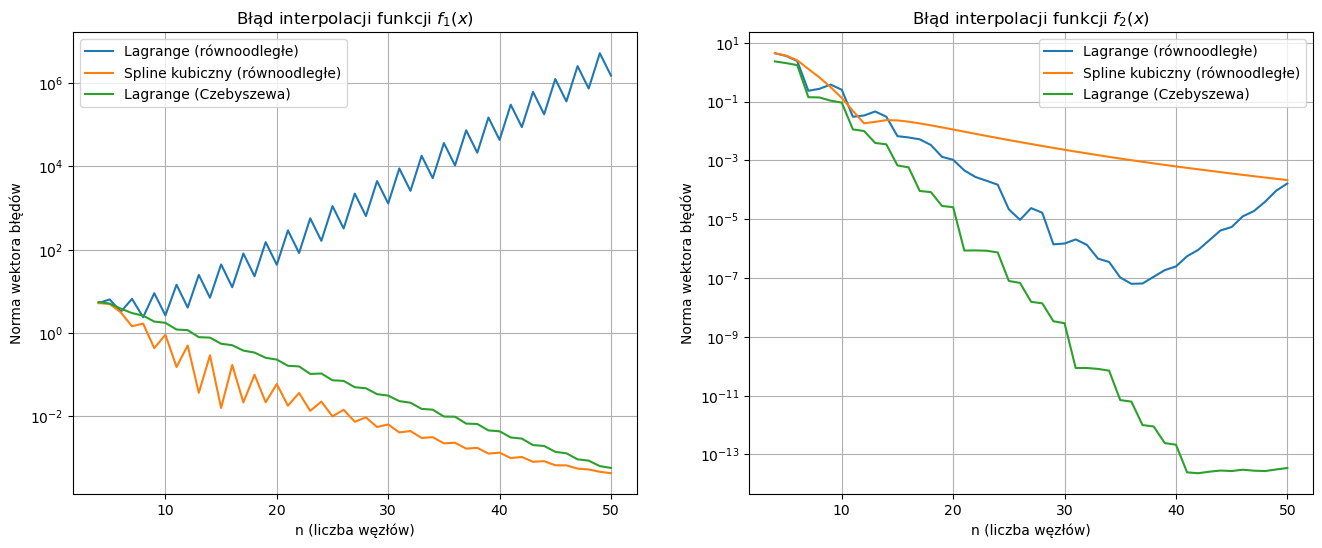

In [7]:
# Podpunkt (b)
np.random.seed(42)
x_test_f1 = np.random.uniform(-1, 1, 500)
x_test_f2 = np.random.uniform(0, 2*np.pi, 500)

ns = range(4, 51)
errors_f1 = {'lagrange_eq': [], 'spline_eq': [], 'lagrange_cheb': []}
errors_f2 = {'lagrange_eq': [], 'spline_eq': [], 'lagrange_cheb': []}

for n in ns:
    # Funkcja f1
    x_eq_f1 = equidistant_nodes(n, -1, 1)
    x_cheb_f1 = chebyshev_nodes(n, -1, 1)
    
    y_lagrange_eq = lagrange_interpolation(x_test_f1, x_eq_f1, f1(x_eq_f1))
    y_spline_eq = interp1d(x_eq_f1, f1(x_eq_f1), kind='cubic')(x_test_f1)
    y_lagrange_cheb = lagrange_interpolation(x_test_f1, x_cheb_f1, f1(x_cheb_f1))
    
    errors_f1['lagrange_eq'].append(np.linalg.norm(f1(x_test_f1) - y_lagrange_eq))
    errors_f1['spline_eq'].append(np.linalg.norm(f1(x_test_f1) - y_spline_eq))
    errors_f1['lagrange_cheb'].append(np.linalg.norm(f1(x_test_f1) - y_lagrange_cheb))
    
    # Funkcja f2
    x_eq_f2 = equidistant_nodes(n, 0, 2*np.pi)
    x_cheb_f2 = chebyshev_nodes(n, 0, 2*np.pi)
    
    y_lagrange_eq2 = lagrange_interpolation(x_test_f2, x_eq_f2, f2(x_eq_f2))
    y_spline_eq2 = interp1d(x_eq_f2, f2(x_eq_f2), kind='cubic')(x_test_f2)
    y_lagrange_cheb2 = lagrange_interpolation(x_test_f2, x_cheb_f2, f2(x_cheb_f2))
    
    errors_f2['lagrange_eq'].append(np.linalg.norm(f2(x_test_f2) - y_lagrange_eq2))
    errors_f2['spline_eq'].append(np.linalg.norm(f2(x_test_f2) - y_spline_eq2))
    errors_f2['lagrange_cheb'].append(np.linalg.norm(f2(x_test_f2) - y_lagrange_cheb2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(ns, errors_f1['lagrange_eq'], label='Lagrange (równoodległe)')
ax1.plot(ns, errors_f1['spline_eq'], label='Spline kubiczny (równoodległe)')
ax1.plot(ns, errors_f1['lagrange_cheb'], label='Lagrange (Czebyszewa)')
ax1.set_yscale('log')
ax1.set_title('Błąd interpolacji funkcji $f_1(x)$')
ax1.set_xlabel('n (liczba węzłów)')
ax1.set_ylabel('Norma wektora błędów')
ax1.legend()
ax1.grid(True)

ax2.plot(ns, errors_f2['lagrange_eq'], label='Lagrange (równoodległe)')
ax2.plot(ns, errors_f2['spline_eq'], label='Spline kubiczny (równoodległe)')
ax2.plot(ns, errors_f2['lagrange_cheb'], label='Lagrange (Czebyszewa)')
ax2.set_yscale('log')
ax2.set_title('Błąd interpolacji funkcji $f_2(x)$')
ax2.set_xlabel('n (liczba węzłów)')
ax2.set_ylabel('Norma wektora błędów')
ax2.legend()
ax2.grid(True)

plt.show()
